In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("C:\AIML\Projects\Real Estate Investment Advisor\cleaned_data.csv")
df.head()

,State,City,Locality,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,...,Furnished_Status_Unfurnished,Clubhouse,Garden,Gym,Playground,Pool,Availability_Status_Ready_to_Move,Availability_Status_Under_Construction,Total_Amenities,Amenity Density Score
0,15,6,483,1,4740,48976000.0,10000.0,1990,22,1,...,0,1,1,1,1,1,1,0,5,19
1,11,33,434,3,2364,19552000.0,8000.0,2008,21,20,...,1,1,1,1,1,1,0,1,5,14
2,13,25,75,2,3642,18379000.0,5000.0,1997,19,27,...,0,1,0,1,1,1,1,0,4,21
3,14,21,326,2,2741,30029000.0,11000.0,1991,21,26,...,0,1,1,1,1,1,1,0,5,18
4,14,19,407,4,4823,18290000.0,4000.0,2002,3,2,...,0,1,1,1,1,1,1,0,5,18


Regression Model: Linear Regression, Random Forest Regressor, or XGBoost Regressor etc. (at least 5)
 Target: Future_Price_5Y


 Regression: Future Price (5 yrs)
Goal: Predict property price in 5 years.
Fixed Rate: Future = Current * (1 + r)^t (e.g., r=8%)


By Location/Type: Use different growth rates per city/property.


Feature-based: Predict growth using property features (BHK, sqft, RERA, etc.)

In [4]:
df['City_Median_PPSF'] = df.groupby('City')['Price_per_SqFt'].transform('median')

In [5]:
df['Relative_Price'] = df['Price_per_SqFt'] / df['City_Median_PPSF']

In [6]:
df['growth_rate'] = (
    0.05
    + 0.01 * df['Public_Transport_Accessibility']
    + 0.005 * df['Amenity Density Score']
    - 0.01 * df['Relative_Price']
)

In [7]:
df['Future_Price_5Y'] = df['Price_in_Lakhs'] * (1 + df['growth_rate']) ** 5

In [8]:
df['Future_Price_5Y'].isnull().sum()

np.int64(0)

In [9]:
X=df.drop(['Future_Price_5Y','Good_Investment','growth_rate','Relative_Price','City_Median_PPSF','Price_in_Lakhs'],axis=1)
y=df['Future_Price_5Y']

In [10]:
df['Future_Price_5Y'].value_counts()

Future_Price_5Y
3.854515e+07    4
1.371314e+07    3
2.188813e+06    3
1.032997e+07    3
4.603231e+07    3
               ..
4.090225e+07    1
4.298496e+06    1
7.590597e+07    1
7.623863e+07    1
3.324414e+07    1
Name: count, Length: 244966, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train=X_train.fillna(X_train.median())
X_test=X_test.fillna(X_test.median())
y_train=y_train.fillna(y_train.median())
y_test=y_test.fillna(y_test.median())

Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression

m1=LinearRegression()
m1.fit(X_train,y_train)

pred1=m1.predict(X_test)


In [14]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_squared_error

rmse=np.sqrt(mean_squared_error(y_test,pred1))
mae=mean_absolute_error(y_test,pred1)
r2=r2_score(y_test,pred1)
mse=mean_squared_error(y_test,pred1)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MSE:",mse)

RMSE: 18731576.124724608
MAE: 15025149.130176753
R2: 0.4108441925405093
MSE: 350871944116352.94


Decision Tree Regressor

In [15]:
from sklearn.tree import DecisionTreeRegressor

m2=DecisionTreeRegressor()
m2.fit(X_train,y_train)

pred2=m2.predict(X_test)

In [16]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_squared_error

rmse=np.sqrt(mean_squared_error(y_test,pred2))
mae=mean_absolute_error(y_test,pred2)
r2=r2_score(y_test,pred2)
mse=mean_squared_error(y_test,pred2)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MSE:",mse)

RMSE: 2794968.730408473
MAE: 2145035.575313829
R2: 0.9868829725720644
MSE: 7811850203961.152


Random Forest Regressor

In [17]:
from sklearn.ensemble import RandomForestRegressor

m3=RandomForestRegressor(
    n_estimators=50,   # fewer trees
    max_depth=10,      # limit tree size
    n_jobs=-1,         # use all CPU cores
    random_state=42
)
m3.fit(X_train,y_train)

pred3=m3.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_squared_error

rmse=np.sqrt(mean_squared_error(y_test,pred3))
mae=mean_absolute_error(y_test,pred3)
r2=r2_score(y_test,pred3)
mse=mean_squared_error(y_test,pred3)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MSE:",mse)

RMSE: 3110193.9557740823
MAE: 2365792.9068512414
R2: 0.9837573657184054
MSE: 9673306442533.635


GradientBoostingRegressor

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

m4=GradientBoostingRegressor()
m4.fit(X_train,y_train)

pred4=m4.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_squared_error

rmse=np.sqrt(mean_squared_error(y_test,pred4))
mae=mean_absolute_error(y_test,pred4)
r2=r2_score(y_test,pred4)
mse=mean_squared_error(y_test,pred4)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MSE:",mse)

RMSE: 3574221.7513378067
MAE: 2820524.496186795
R2: 0.978549149966918
MSE: 12775061127736.297


XGBoost Regressor

In [21]:
from xgboost import XGBRegressor

m5=XGBRegressor()
m5.fit(X_train,y_train)

pred5=m5.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_squared_error

rmse=np.sqrt(mean_squared_error(y_test,pred5))
mae=mean_absolute_error(y_test,pred5)
r2=r2_score(y_test,pred1)
mse=mean_squared_error(y_test,pred5)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MSE:",mse)

RMSE: 1843821.0327803963
MAE: 1459499.3631807184
R2: 0.4108441925405093
MSE: 3399676000923.367


In [23]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(m5, f)

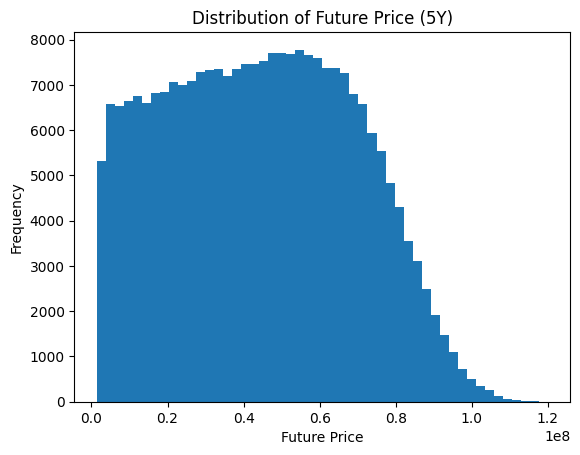

In [24]:
import matplotlib.pyplot as plt

plt.hist(df['Future_Price_5Y'], bins=50)
plt.title("Distribution of Future Price (5Y)")
plt.xlabel("Future Price")
plt.ylabel("Frequency")
plt.show()

EDA

Relationship between infrastructure score and resale value

In [25]:
df['Investment_Score']=(df['Public_Transport_Accessibility']+df['Nearby_Schools']+df['Nearby_Hospitals']+df['Total_Amenities'])

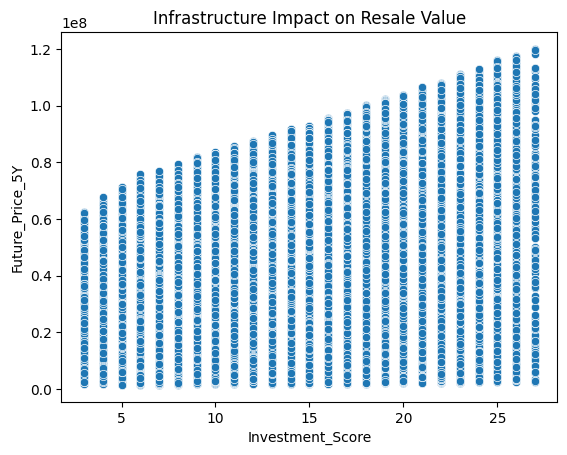

In [26]:
sns.scatterplot(x='Investment_Score',y='Future_Price_5Y',data=df)
plt.title("Infrastructure Impact on Resale Value")
plt.show()

In [27]:
import pickle
import pandas as pd

model = pickle.load(open("model.pkl","rb"))

features = model.feature_names_in_

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20))

                              Feature  Importance
5                      Price_per_SqFt    0.681974
4                        Size_in_SqFt    0.202665
32              Amenity Density Score    0.070867
12     Public_Transport_Accessibility    0.039863
26                                Gym    0.000265
20                Property_Type_Villa    0.000226
1                                City    0.000208
15                          Amenities    0.000206
18            Property_Type_Apartment    0.000192
28                               Pool    0.000190
31                    Total_Amenities    0.000188
16                             Facing    0.000187
2                            Locality    0.000184
23       Furnished_Status_Unfurnished    0.000182
29  Availability_Status_Ready_to_Move    0.000181
17                         Owner_Type    0.000179
11                   Nearby_Hospitals    0.000175
6                          Year_Built    0.000172
24                          Clubhouse    0.000166
